In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('/content/drive/MyDrive/Cleaned_Kenyan_Real_Estate_Prices.csv')
df.head()

,selling price,no_of_bedrooms,has_servant_quarters,property_type,clean_location,zoning_tier
0,130000000,6.0,0,Villa,Kiambu Road,Kiambu/Thika_Road Corridor
1,26950000,4.0,1,Townhouse,Kiambu Road,Kiambu/Thika_Road Corridor
2,16000000,4.0,0,Villa,Ongata Rongai,SatelliteTowns/Commuter Belt
3,45000000,5.0,0,Villa,Ngong,SatelliteTowns/Commuter Belt
4,72000000,5.0,0,Townhouse,Lavington,Premium Nairobi Suburbs


<Axes: >

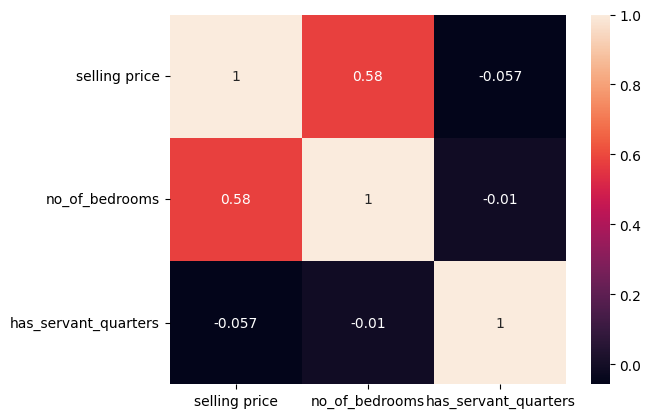

In [6]:
columns_corr = ['selling price','no_of_bedrooms','has_servant_quarters']
df[columns_corr].corr()['selling price']

sns.heatmap(df[columns_corr].corr(),annot=True)



In [40]:
from sklearn.linear_model import LinearRegression, Ridge , Lasso ,RidgeCV , LassoCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

# Feature & Target Split

In [8]:
# Separate the Target(Selling Price ) From the features
X = df.drop('selling price',axis=1)
y = df['selling price']

# Train_test split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (1405, 5)
X_test shape: (352, 5)


In [9]:
# Divide the feature columns as there are some num and some categorical
num_features = ['no_of_bedrooms','has_servant_quarters']
cat_features = ['clean_location','property_type','zoning_tier']

# 1. The Baseline (Every Algorithm Should Beat This)
Imagine you are dropped into Nairobi with zero knowledge of real estate, and someone points at a house and demands, "Guess the exact price of this house right now." You don't know the neighborhood, you don't know the number of bedrooms, and you don't have a calculator. What is the safest, most logical guess you can make?

# The Safest Guess
Your safest guess is to take the average (mean) price of all the houses you’ve ever heard of in the area and guess that exact same number for every single house.

In [23]:
y_train_mean = y_train.mean()
y_train_baseline = [y_train_mean] * len(y_train)
baseline_rmse = root_mean_squared_error(y_train,y_train_baseline)
print(f"Baseline RMSE: {baseline_rmse}")

Baseline RMSE: 40183897.18830761


# 3. Ridge Regression (L2 Regularization)


### Feature Scaling & Pipeline

In [17]:
# Feature scaling
num_transformer = Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='median')),
        ('scaler',StandardScaler())
    ]
)
cat_transformer = OneHotEncoder(handle_unknown='ignore')
preprocessor = ColumnTransformer(
    transformers=[
        ('num',num_transformer,num_features),
        ('cat',cat_transformer,cat_features)
    ]
)

In [30]:
# Steps of the pipeline the tuning knob is at 1.0
ridge_model_pipeline = Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('model',Ridge(alpha=0.1))
])

In [31]:
#Model Training
ridge_model_pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['no_of_bedrooms',
                                                   'has_servant_quarters']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['clean_location',
                                                   'property_type',
                                                   'zoning_tier'])])),
                ('model', Ridge(alpha=0.1))])

# Testing the Memory

You are handing the model the exact same questions (X_train) it just studied during the .fit() phase. You hide the answers (y_train) behind your back and tell the model, "Based on the math you just learned, guess the prices for these houses you've already seen." The model takes those housing features, runs them through its locked-in weights, and outputs its guesses into y_pred_ridge_train.



*   **X_train** = Questions that the model has trained on(features and learnt its pattern)
*   **y_pred_ridge_train** = Answers it generated after i told it to predict

*   **y_train** = Real/Accurate Answers

*   **Error** = Real/Accurate Answers(y_train) - Answers predicted by the model based on Features(y_pred_ridge_train)



In [32]:
y_pred_ridge_train = ridge_model_pipeline.predict(X_train)

rmse_ridge_train = root_mean_squared_error(y_train,y_pred_ridge_train)

print(f"RMSE Ridge Train: {rmse_ridge_train}")

RMSE Ridge Train: 24993107.32889052


# Testing The Intelligence(Generalization Ability)

This is the true final exam. You hand the model the completely unseen test questions (X_test) that were split off at the very beginning. The model has never seen these specific houses before. It applies its weights to these new inputs and saves its blind guesses into y_pred_ridge_test.



*   **X_test** = This is an unseen questions that are been given to the model
*   **y_pred_ridge_test** = This is the predictions made by the model based on the unseen questions it was given


*   **y_test** = Real/Accurate Answers
*   **Error** = Real/Accurate Answers(y_test) - The predictions genrated by the model based on x_test (y_pred_ridge_train)





In [33]:
y_pred_ridge_test = ridge_model_pipeline.predict(X_test)
rmse_ridge_test = root_mean_squared_error(y_test,y_pred_ridge_test)
print(f"RMSE Ridge Test: {rmse_ridge_test}")

RMSE Ridge Test: 25081666.506335955


In [34]:
rmse_train_test_error = rmse_ridge_test - rmse_ridge_train
percentage_error = (rmse_train_test_error/rmse_ridge_train)*100
print(f"Percentage Error: {percentage_error}")

Percentage Error: 0.3543344022016221


# 1. Linear Regression

In [24]:
lr_model_pipeline = Pipeline(
    steps = [
        ('preprocessor',preprocessor),
        ('model',LinearRegression())
    ]
)

In [25]:
lr_model_pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['no_of_bedrooms',
                                                   'has_servant_quarters']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['clean_location',
                                                   'property_type',
                                                   'zoning_tier'])])),
                ('model', LinearRegression())])

In [26]:
y_pred_lr_train = lr_model_pipeline.predict(X_train)
rmse_lr_train = root_mean_squared_error(y_train,y_pred_lr_train)
print(f"RMSE LR Train: {rmse_lr_train}")

RMSE LR Train: 24993041.79462779


In [27]:
y_pred_lr_test = lr_model_pipeline.predict(X_test)
rmse_lr_test = root_mean_squared_error(y_test,y_pred_lr_test)
print(f"RMSE LR Test: {rmse_lr_test}")


RMSE LR Test: 25084263.00007287


In [29]:
percentage_lr_error = (rmse_lr_test - rmse_lr_train)/rmse_lr_train * 100
print(f"Percentage LR Error: {percentage_lr_error}")

Percentage LR Error: 0.36498640779566427


# 4. Lasso Regression (L1 Regularization)

In [35]:
lasso_model_pipeline = Pipeline(
    steps=[
        ('preprocessor',preprocessor),
        ('model',Lasso(alpha=0.1))
    ]
)

In [36]:
lasso_model_pipeline.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 8.717409193405594e+16, tolerance: 226871755850286.94
  model = cd_fast.sparse_enet_coordinate_descent(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['no_of_bedrooms',
                                                   'has_servant_quarters']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['clean_location',
                                                   'property_type',
                                                   'zoning_tier'])])),
                ('model', Lasso(alpha=0.1))])

In [37]:
y_pred_lasso_train = lasso_model_pipeline.predict(X_train)
rmse_lasso_train = root_mean_squared_error(y_train,y_pred_lasso_train)
print(f"RMSE Lasso Train: {rmse_lasso_train}")

RMSE Lasso Train: 24993041.794083234


In [38]:
y_pred_lasso_test = lasso_model_pipeline.predict(X_test)
rmse_lasso_test = root_mean_squared_error(y_test,y_pred_lasso_test)
print(f"RMSE Lasso Test: {rmse_lasso_test}")

RMSE Lasso Test: 25084264.081357814


In [39]:
percentage_lasso_error = (rmse_lasso_test - rmse_lasso_train)/rmse_lasso_train * 100
print(f"Percentage Lasso Error: {percentage_lasso_error}")

Percentage Lasso Error: 0.36499073632636464


# Automated Alpha Selection


In [42]:
# This tests: 0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0
alpha_grid = np.logspace(-4, 3, 8)

#optimized CV Pipelines
ridge_cv_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RidgeCV(alphas=alpha_grid, cv=5))
])

lasso_cv_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LassoCV(alphas=alpha_grid, cv=5, max_iter=50000))
])

In [47]:
# Train models (They will auto-select the best alpha internally)
ridge_cv_pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['no_of_bedrooms',
                                                   'has_servant_quarters']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['clean_location',
                                                   'property_type',
                                                   'zoning_tier'])])),
                ('regressor',
                 RidgeCV(alphas=array([1.e-04, 1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03]),
                         cv=5))])

In [48]:
lasso_cv_pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['no_of_bedrooms',
                                                   'has_servant_quarters']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['clean_location',
                                                   'property_type',
                                                   'zoning_tier'])])),
                ('regressor',
                 LassoCV(alphas=array([1.e-04, 1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03]),
                         cv=5, max_iter=50000))])

In [44]:
#Extraction of the winning alphas chosen by the algorithms
best_ridge_alpha = ridge_cv_pipe.named_steps['regressor'].alpha_
best_lasso_alpha = lasso_cv_pipe.named_steps['regressor'].alpha_

In [45]:
# RidgeCV Evaluation
y_pred_rcv_train = ridge_cv_pipe.predict(X_train)
y_pred_rcv_test  = ridge_cv_pipe.predict(X_test)
rmse_rcv_train   = root_mean_squared_error(y_train, y_pred_rcv_train)
rmse_rcv_test    = root_mean_squared_error(y_test, y_pred_rcv_test)
rcv_gap          = ((rmse_rcv_test - rmse_rcv_train) / rmse_rcv_train) * 100

In [50]:
# LassoCV Evaluation
y_pred_lcv_train = lasso_cv_pipe.predict(X_train)
y_pred_lcv_test  = lasso_cv_pipe.predict(X_test)
rmse_lcv_train   = root_mean_squared_error(y_train, y_pred_lcv_train)
rmse_lcv_test    = root_mean_squared_error(y_test, y_pred_lcv_test)
lcv_gap          = ((rmse_lcv_test - rmse_lcv_train) / rmse_lcv_train) * 100

In [51]:
print(f"--- RIDGE CV RESULTS (Best Alpha: {best_ridge_alpha}) ---")
print(f"Train RMSE: {rmse_rcv_train:,.2f} | Test RMSE: {rmse_rcv_test:,.2f}")
print(f"Generalization Gap: {rcv_gap:.4f}%\n")

print(f"--- LASSO CV RESULTS (Best Alpha: {best_lasso_alpha}) ---")
print(f"Train RMSE: {rmse_lcv_train:,.2f} | Test RMSE: {rmse_lcv_test:,.2f}")
print(f"Generalization Gap: {lcv_gap:.4f}%")

--- RIDGE CV RESULTS (Best Alpha: 10.0) ---
Train RMSE: 25,106,404.76 | Test RMSE: 25,294,474.21
Generalization Gap: 0.7491%

--- LASSO CV RESULTS (Best Alpha: 1000.0) ---
Train RMSE: 24,993,120.13 | Test RMSE: 25,078,562.37
Generalization Gap: 0.3419%


# LassoCV Has The Upper Hand Now

# LassoCV Advantage: Feature Importance

LassoCV utilizes an $L_1$ regularization penalty ($\alpha \sum |\beta|$). This specific geometric penalty has a unique property: as you increase alpha, it drives less important feature weights completely to absolute zero.When LassoCV ran its 5-fold cross-validation loop across the dataset, it realized that at an alpha of 1000.0, it could completely mute the noisy, low-frequency neighborhood columns without damaging the signal of your heavy-hitters like bedroom counts and premium zones.

# Model Ranking & Selection

In [61]:
def generate_model_scoreboard(models_dict, X_train, y_train, X_test, y_test):
    results = []
    for model_name, model_pipeline in models_dict.items():
        y_pred_train = model_pipeline.predict(X_train)
        y_pred_test  = model_pipeline.predict(X_test)
        train_rmse = root_mean_squared_error(y_train, y_pred_train)
        test_rmse  = root_mean_squared_error(y_test, y_pred_test)
        gen_gap_pct = ((test_rmse - train_rmse) / train_rmse) * 100
        results.append({
            "Model Strategy": model_name,
            "Train RMSE (KSh)": train_rmse,
            "Test RMSE (KSh)": test_rmse,
            "Generalization Gap (%)": gen_gap_pct
        })
    df_results = pd.DataFrame(results)
    df_formatted = df_results.copy()
    df_formatted["Train RMSE (KSh)"] = df_formatted["Train RMSE (KSh)"].map("{:,.2f}".format)
    df_formatted["Test RMSE (KSh)"] = df_formatted["Test RMSE (KSh)"].map("{:,.2f}".format)
    df_formatted["Generalization Gap (%)"] = df_formatted["Generalization Gap (%)"].map("{:.4f}%".format)
    return df_formatted
# All Pipelines Fitted in a Dict
my_models = {
    "Standard Linear Regression (OLS)": lr_model_pipeline,
    "Manual Ridge (α=0.1)": ridge_model_pipeline,
    "Manual Lasso (α=0.1)": lasso_model_pipeline,
    "Optimized RidgeCV": ridge_cv_pipe,
    "Optimized LassoCV": lasso_cv_pipe
}
scoreboard = generate_model_scoreboard(my_models, X_train, y_train, X_test, y_test)
print(scoreboard.to_string(index=False))

                  Model Strategy Train RMSE (KSh) Test RMSE (KSh) Generalization Gap (%)
Standard Linear Regression (OLS)    24,993,041.79   25,084,263.00                0.3650%
            Manual Ridge (α=0.1)    24,993,107.33   25,081,666.51                0.3543%
            Manual Lasso (α=0.1)    24,993,041.79   25,084,264.08                0.3650%
               Optimized RidgeCV    25,106,404.76   25,294,474.21                0.7491%
               Optimized LassoCV    24,993,120.13   25,078,562.37                0.3419%


In [63]:
import pickle

model_filename = "lasso_cv_model.pkl"
with open(model_filename, "wb") as file:
    pickle.dump(lasso_cv_pipe, file)